In [1]:
import pandas as pd

train = pd.read_csv("fraudTrain.csv")
test = pd.read_csv("fraudTest.csv")

print("Training shape:", train.shape)
print("Test shape:", test.shape)

print("\nTarget distribution:")
print(train["is_fraud"].value_counts())

print("\nTarget percentage:")
print(
    train["is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\nMissing values:", train.isnull().sum().sum())
print("Duplicate rows:", train.duplicated().sum())

print("\nColumns:")
print(train.columns.tolist())


Training shape: (1296675, 23)
Test shape: (555719, 23)

Target distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Target percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

Missing values: 0
Duplicate rows: 0

Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


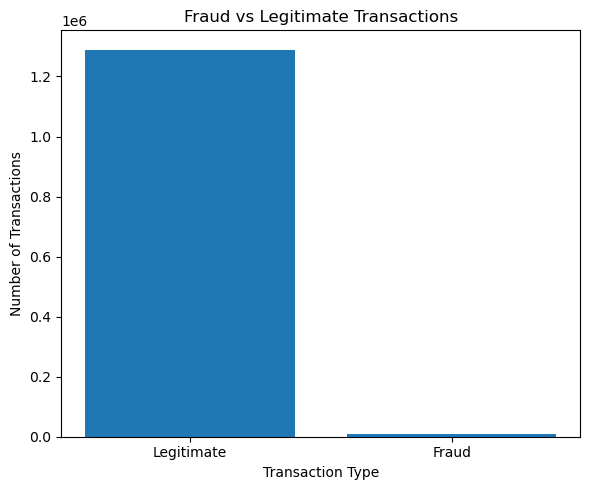

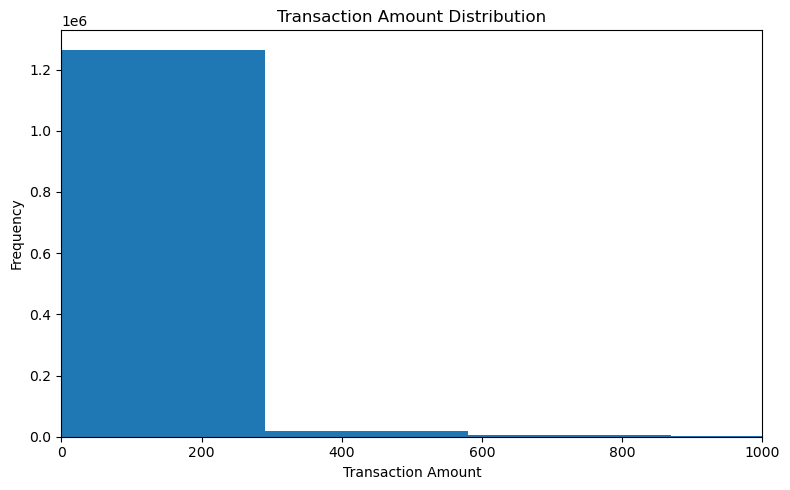

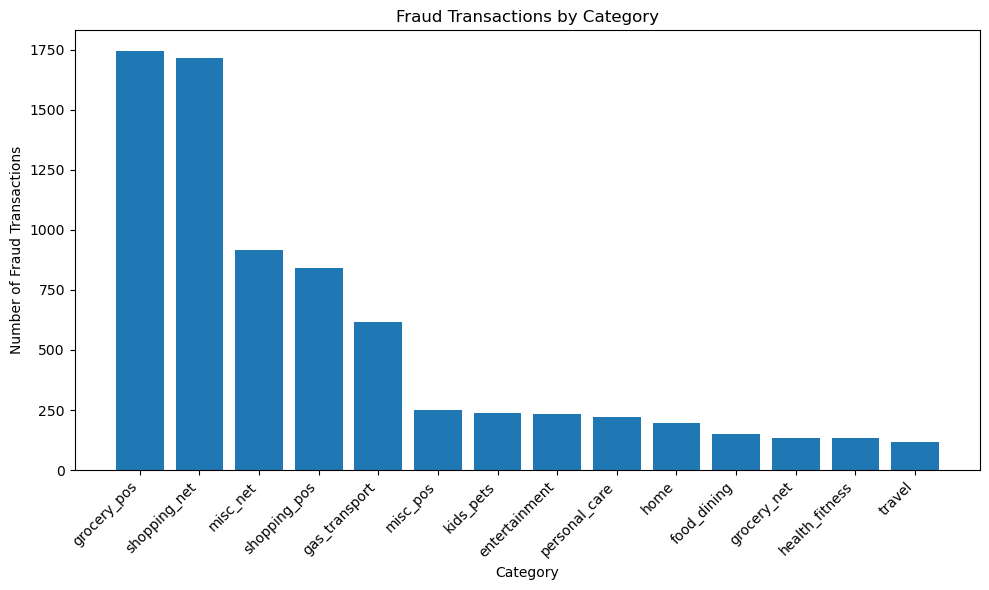

In [2]:
import matplotlib.pyplot as plt

# Fraud distribution
fraud_counts = train["is_fraud"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(
    ["Legitimate", "Fraud"],
    [fraud_counts[0], fraud_counts[1]]
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


# Transaction amount distribution
plt.figure(figsize=(8, 5))
plt.hist(
    train["amt"],
    bins=100
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()


# Fraud by category
fraud_by_category = (
    train.groupby("category")["is_fraud"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(
    fraud_by_category.index,
    fraud_by_category.values
)

plt.title("Fraud Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [4]:
import numpy as np

def prepare_features(df):
    data = df.copy()

    data["trans_date_trans_time"] = pd.to_datetime(
        data["trans_date_trans_time"]
    )

    data["trans_hour"] = data["trans_date_trans_time"].dt.hour
    data["trans_day_of_week"] = data["trans_date_trans_time"].dt.dayofweek
    data["trans_month"] = data["trans_date_trans_time"].dt.month

    data["dob"] = pd.to_datetime(data["dob"])

    data["age"] = (
        data["trans_date_trans_time"].dt.year
        - data["dob"].dt.year
    )

    data["log_amt"] = np.log1p(data["amt"])

    lat_difference = (
        data["lat"] - data["merch_lat"]
    )

    long_difference = (
        data["long"] - data["merch_long"]
    )

    data["location_distance"] = np.sqrt(
        lat_difference ** 2 +
        long_difference ** 2
    )

    columns_to_drop = [
        "Unnamed: 0",
        "trans_date_trans_time",
        "cc_num",
        "merchant",
        "first",
        "last",
        "street",
        "city",
        "zip",
        "job",
        "dob",
        "trans_num",
        "unix_time"
    ]

    data = data.drop(
        columns=columns_to_drop
    )

    return data

In [5]:
train_processed = prepare_features(train)
test_processed = prepare_features(test)

print(train_processed.shape)
print(test_processed.shape)

print(train_processed.head())

(1296675, 16)
(555719, 16)
        category     amt gender state      lat      long  city_pop  merch_lat  \
0       misc_net    4.97      F    NC  36.0788  -81.1781      3495  36.011293   
1    grocery_pos  107.23      F    WA  48.8878 -118.2105       149  49.159047   
2  entertainment  220.11      M    ID  42.1808 -112.2620      4154  43.150704   
3  gas_transport   45.00      M    MT  46.2306 -112.1138      1939  47.034331   
4       misc_pos   41.96      M    VA  38.4207  -79.4629        99  38.674999   

   merch_long  is_fraud  trans_hour  trans_day_of_week  trans_month  age  \
0  -82.048315         0           0                  1            1   31   
1 -118.186462         0           0                  1            1   41   
2 -112.154481         0           0                  1            1   57   
3 -112.561071         0           0                  1            1   52   
4  -78.632459         0           0                  1            1   33   

    log_amt  location_distanc

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)



# 1. SEPARATE FEATURES AND TARGET


X = train_processed.drop(
    columns=["is_fraud"]
)

y = train_processed["is_fraud"]



# 2. IDENTIFY COLUMN TYPES


categorical_features = [
    "category",
    "gender",
    "state"
]

numerical_features = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long",
    "trans_hour",
    "trans_day_of_week",
    "trans_month",
    "age",
    "log_amt",
    "location_distance"
]



# 3. PREPROCESSING


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)



# 4. TRAIN / VALIDATION SPLIT


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))



# 5. LOGISTIC REGRESSION


logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_valid
)

logistic_prob = logistic_model.predict_proba(
    X_valid
)[:, 1]


print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

print(
    "Accuracy:",
    accuracy_score(y_valid, logistic_pred)
)

print(
    "Precision:",
    precision_score(
        y_valid,
        logistic_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_valid,
        logistic_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_valid,
        logistic_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        logistic_prob
    )
)



# 6. DECISION TREE


decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42,
                max_depth=12
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

tree_pred = decision_tree_model.predict(
    X_valid
)

tree_prob = decision_tree_model.predict_proba(
    X_valid
)[:, 1]


print("\n==============================")
print("DECISION TREE")
print("==============================")

print(
    "Accuracy:",
    accuracy_score(y_valid, tree_pred)
)

print(
    "Precision:",
    precision_score(
        y_valid,
        tree_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_valid,
        tree_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_valid,
        tree_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        tree_prob
    )
)


# --------------------------------------------------
# 7. RANDOM FOREST
# --------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                max_depth=12
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

forest_pred = random_forest_model.predict(
    X_valid
)

forest_prob = random_forest_model.predict_proba(
    X_valid
)[:, 1]


print("\n==============================")
print("RANDOM FOREST")
print("==============================")

print(
    "Accuracy:",
    accuracy_score(y_valid, forest_pred)
)

print(
    "Precision:",
    precision_score(
        y_valid,
        forest_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_valid,
        forest_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_valid,
        forest_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_valid,
        forest_prob
    )
)

Training samples: 1037340
Validation samples: 259335

LOGISTIC REGRESSION
Accuracy: 0.9294156207222318
Precision: 0.06375908618899273
Recall: 0.8181212524983345
F1: 0.11829873320167622
ROC-AUC: 0.9393103130043796

DECISION TREE
Accuracy: 0.9777006574507876
Precision: 0.20189362294625451
Recall: 0.966022651565623
F1: 0.3339859495566049
ROC-AUC: 0.9838556036682098

RANDOM FOREST
Accuracy: 0.9869165365261149
Precision: 0.2957685664939551
Recall: 0.9127248500999334
F1: 0.44676341105494866
ROC-AUC: 0.9950313795679403


In [8]:
X_test = test_processed.drop(
    columns=["is_fraud"]
)

y_test = test_processed["is_fraud"]


# Predict class
test_pred = random_forest_model.predict(X_test)

# Predict fraud probability
test_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]


print("\n==============================")
print("FINAL RANDOM FOREST TEST RESULTS")
print("==============================")

print(
    "Accuracy:",
    accuracy_score(y_test, test_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        test_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        test_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        test_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        test_prob
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_pred
    )
)


FINAL RANDOM FOREST TEST RESULTS
Accuracy: 0.9889638468362608
Precision: 0.24650394101195017
Recall: 0.903962703962704
F1: 0.38737388872240536
ROC-AUC: 0.9937527504571838

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.25      0.90      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.95      0.69    555719
weighted avg       1.00      0.99      0.99    555719


Confusion Matrix:
[[547647   5927]
 [   206   1939]]


In [9]:
import joblib

joblib.dump(
    random_forest_model,
    "fraud_detection_pipeline.pkl"
)

print("Fraud detection pipeline saved successfully.")

Fraud detection pipeline saved successfully.


In [10]:
import os

print(os.path.exists("fraud_detection_pipeline.pkl"))

True


In [12]:
import joblib

joblib.dump(
    random_forest_model,
    "fraud_detection_pipeline.pkl"
)

print("Saved successfully")

Saved successfully
